# ARK Invest: Skill or Luck?

In [31]:
# ── Librerie base ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualizzazione ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Econometria / Statistica ───────────────────────────────────────────────────
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.compat import lzip
from statsmodels.regression.rolling import RollingOLS
from statsmodels.datasets import longley
from statsmodels.iolib.summary2 import summary_col
from statsmodels.tsa.stattools import adfuller

from scipy import stats
from scipy.stats import norm, linregress

# ── Machine Learning / PCA / Clustering ───────────────────────────────────────
from sklearn.decomposition import PCA
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

# ── Ottimizzazione portafoglio ─────────────────────────────────────────────────
from pypfopt import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns

# ── Dati finanziari ────────────────────────────────────────────────────────────
import yfinance as yf
import fmfinance as fm
import financedatabase as fd
import quantstats as qs
pd.set_option('display.max_rows', 20)  # ripristina il default

# ── Calcolo parallelo ──────────────────────────────────────────────────────────
from joblib import Parallel, delayed

# ── Interfaccia R ──────────────────────────────────────────────────────────────
import rpy2.robjects as ro
from rpy2.robjects.packages import importr

# ── Web scraping ───────────────────────────────────────────────────────────────
import requests
from bs4 import BeautifulSoup
from io import StringIO

# ── UI interattiva ─────────────────────────────────────────────────────────────
import ipywidgets as widgets
from IPython.display import display

# ── Utility ────────────────────────────────────────────────────────────────────
from datetime import datetime
from pandas.plotting import register_matplotlib_converters
import random
import time
import os
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Data Setup

In [32]:
start = '2019-01-01'
end = '2024-12-31'
split = '2022-12-31'

ff4f = fm.ff('4_factors', start, end)[0]

tickers = ['ARKK', 'ARKW', 'ARKG', 'ARKF', 'ARKQ', 'SPY']
prices = yf.download(tickers, start=start, end=end,
                     auto_adjust=False, multi_level_index=False, interval='1mo')['Adj Close']

display(ff4f)
display(prices)

[*********************100%***********************]  6 of 6 completed


,Mkt-RF,SMB,HML,Mom,RF
Date,,,,,
2019-01-01,8.37,2.76,-0.39,-8.62,0.21
2019-02-01,3.42,2.05,-2.66,0.50,0.18
2019-03-01,1.10,-3.03,-4.14,2.24,0.19
2019-04-01,3.97,-1.74,2.13,-2.91,0.21
2019-05-01,-6.92,-1.26,-2.45,7.55,0.21
...,...,...,...,...,...
2024-08-01,1.60,-3.50,-1.10,4.86,0.48
2024-09-01,1.72,-0.12,-2.77,-0.56,0.40
2024-10-01,-1.00,-0.96,0.89,2.94,0.39


Ticker,ARKF,ARKG,ARKK,ARKQ,ARKW,SPY
Date,,,,,,
2019-01-01,NaN,27.011171,41.523792,32.629162,46.841206,242.096024
2019-02-01,20.852493,29.461514,44.909355,34.610847,49.130291,249.943710
2019-03-01,21.196594,31.471558,45.073330,33.394367,49.007328,253.351822
2019-04-01,22.278053,31.308840,45.545959,33.959446,50.482929,264.863495
2019-05-01,20.685360,27.872620,39.286045,28.783514,45.015606,247.972839
...,...,...,...,...,...,...
2024-08-01,28.275276,26.389999,44.820000,56.085991,77.984314,552.062866
2024-09-01,29.793949,25.600000,47.529999,60.763977,83.833870,561.935120
2024-10-01,30.843033,23.139999,45.889999,60.823826,85.636009,558.628967


In [33]:
returns    = prices.pct_change()*100
returns.dropna(inplace=True)
returns

Ticker,ARKF,ARKG,ARKK,ARKQ,ARKW,SPY
Date,,,,,,
2019-03-01,1.650167,6.822610,0.365124,-3.514737,-0.250279,1.363552
2019-04-01,5.102042,-0.517031,1.048579,1.692138,3.010981,4.543750
2019-05-01,-7.149158,-10.975240,-13.744171,-15.241509,-10.830044,-6.377117
2019-06-01,7.652092,18.372261,17.800136,15.064750,9.287661,6.440960
2019-07-01,0.958059,0.319122,1.000415,-2.073456,0.903675,2.005656
...,...,...,...,...,...,...
2024-08-01,3.967675,-2.077927,-1.559409,-0.530686,1.799718,2.336543
2024-09-01,5.371028,-2.993554,6.046406,8.340739,7.500939,1.788248
2024-10-01,3.521130,-9.609379,-3.450451,0.098494,2.149655,-0.588351


In [34]:
rf = ff4f['RF']
er = returns.subtract(rf, axis=0).dropna()

display(er.round(2))

Ticker,ARKF,ARKG,ARKK,ARKQ,ARKW,SPY
Date,,,,,,
2019-03-01,1.46,6.63,0.18,-3.70,-0.44,1.17
2019-04-01,4.89,-0.73,0.84,1.48,2.80,4.33
2019-05-01,-7.36,-11.19,-13.95,-15.45,-11.04,-6.59
2019-06-01,7.47,18.19,17.62,14.88,9.11,6.26
2019-07-01,0.77,0.13,0.81,-2.26,0.71,1.82
...,...,...,...,...,...,...
2024-08-01,3.49,-2.56,-2.04,-1.01,1.32,1.86
2024-09-01,4.97,-3.39,5.65,7.94,7.10,1.39
2024-10-01,3.13,-10.00,-3.84,-0.29,1.76,-0.98


## Return Analysis

In [35]:
# ── Statistiche descrittive comparative (Fase 1) ──────────────────────────────
# Tutti gli ETF + SPY, dati mensili → periods_per_year=12
# Pattern ripreso da Es01_Return_Analysis.ipynb

etf_tickers = ['ARKF', 'ARKG', 'ARKK', 'ARKQ', 'ARKW']

# Rendimenti in eccesso in formato decimale per quantstats
er_qs = er[etf_tickers] / 100

# Loop su ogni strumento per raccogliere le metriche
statistiche = {}

for ticker in etf_tickers:
    rets = er_qs[ticker].dropna()
    statistiche[ticker] = {
        'Media mensile (%)':    round(er[ticker].mean(), 3),
        'Std. Dev. mensile (%)': round(er[ticker].std(), 3),
        'Skewness':             round(er[ticker].skew(), 3),
        'Curtosi (excess)':     round(er[ticker].kurt(), 3),
        'Min (%)':              round(er[ticker].min(), 3),
        'Max (%)':              round(er[ticker].max(), 3),
        'CAGR (%)': round(qs.stats.cagr(rets, periods=12) * 100, 3),
        'Volatilità ann. (%)':  round(qs.stats.volatility(rets, periods=12) * 100, 3),
        'Sharpe (ann.)':        round(qs.stats.sharpe(rets, periods=12), 3),
        'Sortino (ann.)':       round(qs.stats.sortino(rets, periods=12), 3),
        'Max Drawdown (%)':     round(qs.stats.max_drawdown(rets) * 100, 3),
        'VaR 5% (%)':           round(qs.stats.value_at_risk(rets, sigma=0.05) * 100, 3),
        'CVaR 5% (%)':          round(qs.stats.cvar(rets, confidence=0.95) * 100, 3),
    }

# Costruzione DataFrame trasposto (metriche per riga, ETF per colonna)
df_stats = pd.DataFrame(statistiche)
display(df_stats)

,ARKF,ARKG,ARKK,ARKQ,ARKW
Media mensile (%),1.255,0.152,0.880,1.339,1.570
Std. Dev. mensile (%),11.314,11.705,12.379,8.931,11.617
Skewness,0.199,0.292,0.372,0.364,0.218
Curtosi (excess),0.231,-0.401,-0.177,-0.107,-0.156
Min (%),-27.022,-25.974,-28.903,-16.302,-26.542
Max (%),29.737,30.083,31.002,25.477,28.807
CAGR (%),7.844,-6.023,1.709,12.088,11.570
Volatilità ann. (%),39.194,40.548,42.883,30.937,40.244
Sharpe (ann.),0.384,0.045,0.246,0.519,0.468
Sortino (ann.),0.617,0.069,0.404,0.901,0.777


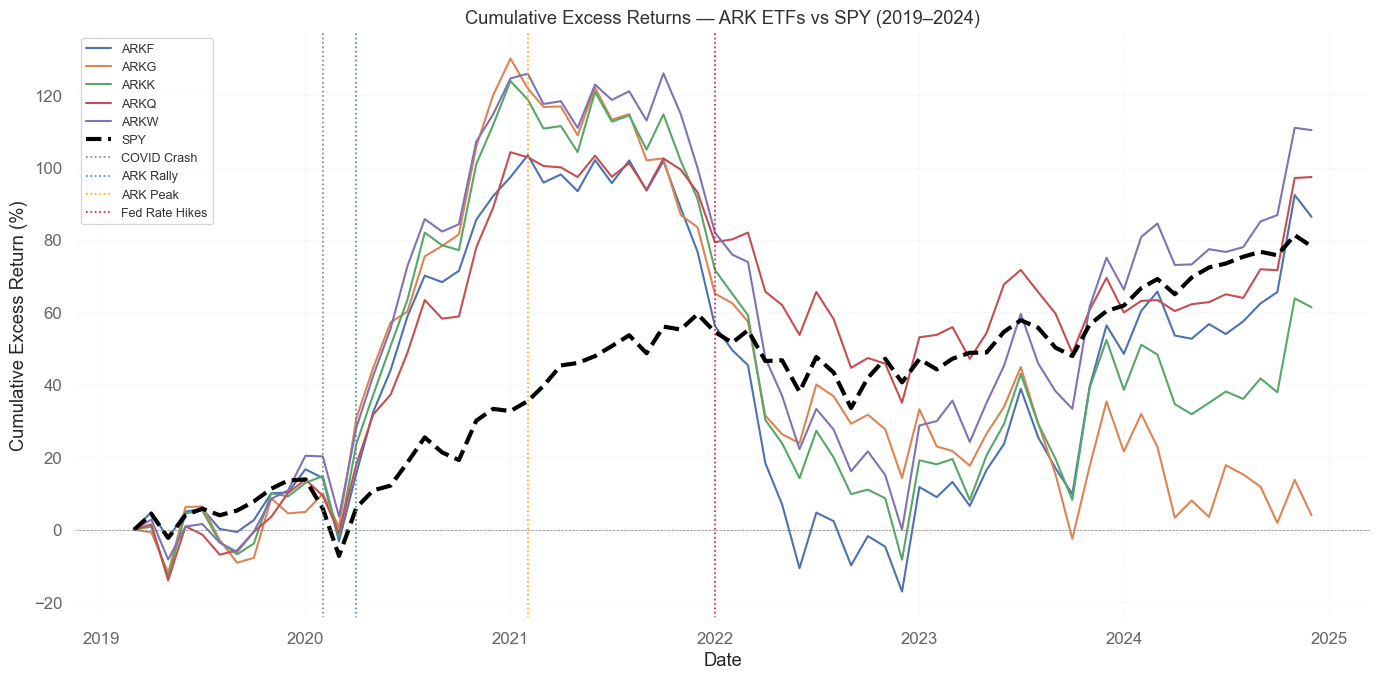

In [36]:
# Rendimenti cumulati
cum_er = er[etf_tickers + ['SPY']].cumsum()
cum_er = cum_er - cum_er.bfill().iloc[0]

fig, ax = plt.subplots(figsize=(14, 7))

# ETF ARK
for ticker in etf_tickers:
    ax.plot(cum_er.index, cum_er[ticker], label=ticker, linewidth=1.5)

# SPY evidenziato
ax.plot(cum_er.index, cum_er['SPY'], label='SPY', linewidth=3, 
        color='black', linestyle='--')

# Linee verticali
ax.axvline(pd.Timestamp('2020-02-01'), color='gray',     linestyle=':', linewidth=1.2, label='COVID Crash')
ax.axvline(pd.Timestamp('2020-04-01'), color='steelblue',linestyle=':', linewidth=1.2, label='ARK Rally')
ax.axvline(pd.Timestamp('2021-02-01'), color='orange',   linestyle=':', linewidth=1.2, label='ARK Peak')
ax.axvline(pd.Timestamp('2022-01-01'), color='crimson',  linestyle=':', linewidth=1.2, label='Fed Rate Hikes')

ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_title('Cumulative Excess Returns — ARK ETFs vs SPY (2019–2024)')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Excess Return (%)')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Il grafico mostra l'evoluzione dei rendimenti cumulati in eccesso per i cinque ETF
ARK e il benchmark SPY sull'intero periodo di analisi.

Fino al COVID crash (febbraio 2020) tutti gli strumenti si muovono in modo simile
e contenuto. Dal rimbalzo di aprile 2020 i fondi ARK accelerano bruscamente rispetto
a SPY, raggiungendo rendimenti cumulati di oltre 120–140% al picco di febbraio 2021,
mentre SPY si fermava intorno al 60%.

Con l'inversione di tendenza del 2022 — accentuata dai rialzi dei tassi Fed — i fondi
ARK restituiscono quasi interamente i guadagni accumulati, scendendo in alcuni casi
sotto zero (ARKF). SPY mostra invece un drawdown molto più contenuto (~-24%).

Nel biennio 2023–2024 si assiste a una parziale ripresa, con ARKW e ARKQ che
recuperano terreno, mentre ARKG rimane il fondo più debole dell'universo.

La correlazione visiva molto elevata tra i cinque ETF ARK conferma quanto emerso
dalla matrice di correlazione: i fondi condividono un'esposizione comune che li rende
sostanzialmente intercambiabili in termini di profilo rischio-rendimento.

In [37]:
display(er.round(2))

Ticker,ARKF,ARKG,ARKK,ARKQ,ARKW,SPY
Date,,,,,,
2019-03-01,1.46,6.63,0.18,-3.70,-0.44,1.17
2019-04-01,4.89,-0.73,0.84,1.48,2.80,4.33
2019-05-01,-7.36,-11.19,-13.95,-15.45,-11.04,-6.59
2019-06-01,7.47,18.19,17.62,14.88,9.11,6.26
2019-07-01,0.77,0.13,0.81,-2.26,0.71,1.82
...,...,...,...,...,...,...
2024-08-01,3.49,-2.56,-2.04,-1.01,1.32,1.86
2024-09-01,4.97,-3.39,5.65,7.94,7.10,1.39
2024-10-01,3.13,-10.00,-3.84,-0.29,1.76,-0.98


In [38]:
# Matrice di correlazione
er[etf_tickers].corr().style.background_gradient(cmap='coolwarm', vmin=0, vmax=1)

Ticker,ARKF,ARKG,ARKK,ARKQ,ARKW
Ticker,,,,,
ARKF,1.000000,0.816518,0.937567,0.862174,0.971968
ARKG,0.816518,1.000000,0.912701,0.807723,0.834143
ARKK,0.937567,0.912701,1.000000,0.914741,0.967251
ARKQ,0.862174,0.807723,0.914741,1.000000,0.901813
ARKW,0.971968,0.834143,0.967251,0.901813,1.000000


Nonostante i diversi temi dichiarati (genomica, fintech, robotica…), i cinque fondi condividono un'esposizione fattoriale comune talmente forte, alta esposizione a Mkt-RF, SMB positivo, HML negativo, da renderli sostanzialmente intercambiabili dal punto di vista del profilo rischio-rendimento. 

## Carhart 

In [39]:
# Allineamento fattori e excess returns — solo periodo in-sample
capm4 = pd.concat([ff4f, er], axis=1).dropna()
capm4_is = capm4.loc[:split]
capm4_oos = capm4.loc[split:]

x1 = capm4_is[['Mkt-RF', 'SMB', 'HML', 'Mom']]
x  = sm.add_constant(x1)
y  = capm4_is[etf_tickers]

# Regressioni OLS — modello Carhart a 4 fattori
regr_4f = []
for i in range(len(y.columns)):
    regr_4f.append(sm.OLS(y.iloc[:, i], x).fit())

summary_col(regr_4f, stars=True)

,ARKF,ARKG,ARKK,ARKQ,ARKW
const,-1.4869**,0.0620,-1.1241,-0.2403,-1.1284
,(0.7311),(0.8057),(0.7940),(0.5576),(0.7852)
Mkt-RF,1.4779***,1.1327***,1.5141***,1.2487***,1.5252***
,(0.1439),(0.1585),(0.1562),(0.1097),(0.1545)
SMB,1.1277***,1.6153***,1.4612***,1.1960***,1.2900***
,(0.2829),(0.3117),(0.3072),(0.2157),(0.3038)
HML,-0.5102***,-0.9689***,-0.7952***,-0.3347***,-0.6250***
,(0.1566),(0.1726),(0.1701),(0.1195),(0.1682)
Mom,0.3357,-0.2386,0.0995,0.2112,0.2988
,(0.2158),(0.2378),(0.2344),(0.1646),(0.2318)


In [40]:
capm4_is

,Mkt-RF,SMB,HML,Mom,RF,ARKF,ARKG,ARKK,ARKQ,ARKW,SPY
Date,,,,,,,,,,,
2019-03-01,1.10,-3.03,-4.14,2.24,0.19,1.460167,6.632610,0.175124,-3.704737,-0.440279,1.173552
2019-04-01,3.97,-1.74,2.13,-2.91,0.21,4.892042,-0.727031,0.838579,1.482138,2.800981,4.333750
2019-05-01,-6.92,-1.26,-2.45,7.55,0.21,-7.359158,-11.185240,-13.954171,-15.451509,-11.040044,-6.587117
2019-06-01,6.99,0.11,-0.64,-2.24,0.18,7.472092,18.192261,17.620136,14.884750,9.107661,6.260960
2019-07-01,1.23,-1.96,0.50,2.92,0.19,0.768059,0.129122,0.810415,-2.263456,0.713675,1.815656
...,...,...,...,...,...,...,...,...,...,...,...
2022-08-01,-3.77,1.41,0.18,1.98,0.19,-2.371201,-3.249270,-7.391414,-7.503601,-5.733316,-4.270184
2022-09-01,-9.34,-0.76,0.03,3.71,0.19,-12.196857,-7.572369,-10.099275,-13.450198,-11.499754,-9.805873
2022-10-01,7.85,0.01,7.97,3.91,0.23,8.087090,2.477634,1.227729,2.698779,5.510576,8.341711


In [41]:
capm4_oos

,Mkt-RF,SMB,HML,Mom,RF,ARKF,ARKG,ARKK,ARKQ,ARKW,SPY
Date,,,,,,,,,,,
2023-01-01,6.61,5.01,-3.94,-16.21,0.35,28.872143,19.026554,27.466906,18.084528,28.806936,6.426800
2023-02-01,-2.57,1.05,-0.80,0.54,0.34,-2.780352,-10.280654,-1.116363,0.668856,1.206498,-2.854258
2023-03-01,2.48,-5.48,-9.05,-2.35,0.36,4.198082,-1.282572,1.457268,2.147139,5.672437,2.953496
2023-04-01,0.62,-3.37,-0.12,1.75,0.35,-6.623256,-4.041389,-11.306873,-8.761221,-11.430026,1.635241
2023-05-01,0.34,1.60,-7.79,-0.86,0.36,9.963318,8.859614,12.362722,7.173652,10.842015,0.101608
...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,1.60,-3.50,-1.10,4.86,0.48,3.487675,-2.557927,-2.039409,-1.010686,1.319718,1.856543
2024-09-01,1.72,-0.12,-2.77,-0.56,0.40,4.971028,-3.393554,5.646406,7.940739,7.100939,1.388248
2024-10-01,-1.00,-0.96,0.89,2.94,0.39,3.131130,-9.999379,-3.840451,-0.291506,1.759655,-0.978351


In [42]:
for i, ticker in enumerate(etf_tickers):
    print(f"{ticker} — F-stat: {regr_4f[i].fvalue:.2f}, p-value: {regr_4f[i].f_pvalue:.2e}")

ARKF — F-stat: 44.81, p-value: 1.91e-14
ARKG — F-stat: 43.19, p-value: 3.50e-14
ARKK — F-stat: 50.58, p-value: 2.53e-15
ARKQ — F-stat: 60.30, p-value: 1.24e-16
ARKW — F-stat: 44.68, p-value: 2.00e-14


**Alpha (const)** — solo ARKF mostra un alpha statisticamente significativo (-1.49**, 
pari a circa -18% annuo). Gli alpha degli altri fondi sono negativi ma non significativi: 
non si può escludere che siano rumore statistico. Il risultato chiave è che **nessun 
fondo genera alpha positivo significativo** — la performance è prevalentemente 
attribuibile alle esposizioni fattoriali sistematiche.

**Beta di mercato (Mkt-RF)** — tutti i coefficienti sono positivi, compresi tra 1.13 
(ARKG) e 1.52 (ARKW), e significativi al 99%. Tutti i fondi ARK amplificano i movimenti 
di mercato: un rialzo del 10% del mercato si traduce in un guadagno di circa 13–15% 
per gli ETF ARK. Questo implica che buona parte della performance straordinaria del 
2020 era semplicemente il mercato che saliva, amplificato dal beta elevato.

**SMB** — tutti positivi e significativi al 99%, compresi tra 1.13 (ARKF) e 1.62 (ARKG). 
I fondi ARK si comportano come portafogli di small cap: quando le piccole capitalizzazioni 
sovraperformano le grandi, gli ETF ARK ne beneficiano in modo amplificato. Coerente con 
la strategia di investire in aziende innovative giovani e di piccola/media dimensione.

**HML** — tutti negativi e significativi al 99%, compresi tra -0.33 (ARKQ) e -0.97 (ARKG). 
Conferma strutturalmente l'impronta growth di ARK: i fondi sovrappesano titoli con alto 
price-to-book e basso valore contabile, ovvero l'opposto dei titoli value.

**Mom** — nessun coefficiente è significativo. Il fattore momentum non contribuisce 
a spiegare i rendimenti ARK nel periodo in-sample.

**R²** — tutti intorno a 0.81. Circa l'80% della variabilità mensile dei rendimenti 
è spiegata dai quattro fattori. Lo spazio per lo stock-picking idiosincratico è limitato.

## Rolling Analysis

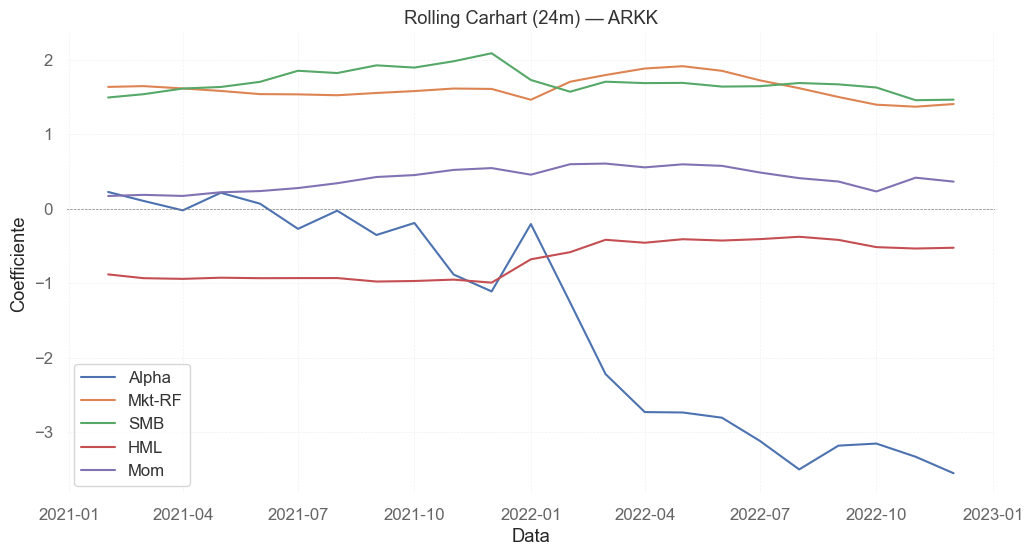

In [43]:
# Stima rolling 24 mesi — ARKK
m1_rolling = RollingOLS(capm4_is['ARKK'], x, window=24).fit()
params = m1_rolling.params

# Grafico
plt.figure(figsize=(12, 6))
plt.plot(params.index, params['const'],  label='Alpha',  linewidth=1.5)
plt.plot(params.index, params['Mkt-RF'], label='Mkt-RF', linewidth=1.5)
plt.plot(params.index, params['SMB'],    label='SMB',    linewidth=1.5)
plt.plot(params.index, params['HML'],    label='HML',    linewidth=1.5)
plt.plot(params.index, params['Mom'],    label='Mom',    linewidth=1.5)

plt.axhline(0, color='gray', linewidth=0.5, linestyle='--')
plt.title('Rolling Carhart (24m) — ARKK')
plt.xlabel('Data')
plt.ylabel('Coefficiente')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

La regressione Carhart stimata su finestra mobile di 24 mesi permette di osservare
come le esposizioni fattoriali di ARKK si sono evolute nel tempo.

**Mkt-RF** e **SMB** risultano stabili per tutto il periodo (rispettivamente ~1.5 e ~1.7),
confermando un'esposizione persistente al mercato e alle small cap indipendentemente
dal regime.

**HML** rimane costantemente negativo (~-1), coerente con l'impronta growth della
strategia ARK: il fondo sovrapesa titoli a basso book-to-market.

**Mom** rimane vicino a zero per tutto il periodo, con una leggera risalita verso
fine 2022, il fattore momentum non sembra essere un driver rilevante per ARKK.

La serie più informativa è **Alpha**: positivo e stabile fino a metà 2021, crolla
drasticamente fino a -3.5 nel corso del 2022. Questo indica che, una volta entrati
nel regime bear, i rendimenti di ARKK non solo erano spiegati dai fattori sistematici,
ma mostravano una distruzione di valore idiosincratica persistente, la performance
negativa non era interamente attribuibile alle esposizioni fattoriali.

## Bootstrap

In [44]:
# Fattori e fondi in-sample
factors_is = capm4_is[['Mkt-RF', 'SMB', 'HML', 'Mom']]
funds_is   = capm4_is[etf_tickers]

# Bootstrap cross-sezionale — Cuthbertson et al. (2008)
np.random.seed(42)
alpha_obs, alpha_t_obs, alphas_boot, t_alphas_boot = fm.bootstrap(
    factors_is,
    funds_is,
    n_boot=1000,
    min_obs=24
)

In [45]:
luck_d = pd.DataFrame((np.sort(np.array(t_alphas_boot))))
luck_d.index = [f"sim_{i+1}" for i in range(len(luck_d))]

luck_d.round(2)

,0,1,2,3,4
sim_1,-0.61,0.07,0.43,0.53,0.67
sim_2,-1.11,-0.04,0.11,0.27,2.13
sim_3,-1.15,-0.02,0.08,1.63,2.97
sim_4,-3.04,-1.52,-0.88,0.45,2.12
sim_5,-2.14,-1.33,0.50,0.82,1.08
...,...,...,...,...,...
sim_996,-1.69,0.74,0.75,0.95,1.05
sim_997,-1.22,-0.45,-0.33,-0.02,1.26
sim_998,-1.71,-1.36,-0.61,-0.50,0.83
sim_999,-1.83,-1.08,-0.50,0.07,0.19


In [46]:
# Ordina i t-alpha reali dal peggiore al migliore
# ogni titolo acquisisce un rango che corrisponde alla stessa colonna di luck_d
sorted_original = pd.DataFrame(alpha_t_obs.sort_values(ascending=True))

# Per ogni rango, calcola il 95° percentile delle 1000 simulazioni
# → è la soglia massima ottenibile per pura fortuna a quella posizione in classifica
perc95 = pd.DataFrame(np.percentile(luck_d.T, 95, axis=1)).set_index(sorted_original.index)

# Un titolo è SKILLED solo se supera entrambe le condizioni:
# 1) il suo t-alpha reale batte la soglia di fortuna del suo rango
# 2) l'alpha è positivo
luck_sig = (sorted_original.iloc[:, 0] > perc95.iloc[:, 0]) & (sorted_original.iloc[:, 0] > 0)
skilled_list = sorted_original[luck_sig]

print(f"Fondi identificati come SKILLED (Luck Distribution): {len(skilled_list)}")
skilled_list.sort_values(by=skilled_list.columns[0], ascending=False)

# Estrazione lista ticker skilled → usata nel Punto 4 per costruire il portafoglio
skilled_tickers = skilled_list.index.tolist()
skilled_tickers

Fondi identificati come SKILLED (Luck Distribution): 0


[]

In [47]:
# Test OLS classico: titoli con t-alpha > 1.645 (soglia normale al 95%)
# → ignora il problema dei test multipli su un campione ampio
ols_sig = sorted_original.iloc[:, 0] > norm.ppf(0.95)

# Confronto tra i due metodi di selezione:
# CONFERMATI → skilled per entrambi i metodi: vera abilità
# DROPOUTS   → significativi OLS ma non luck dist: erano solo fortunati
# ADDITIONS  → non significativi OLS ma skilled luck dist: abilità sottovalutata
confermati = (ols_sig == True) & (luck_sig == True)
dropouts = (ols_sig == True) & (luck_sig == False)
additions = (ols_sig == False) & (luck_sig == True)

print("--- COMPARISON: OLS vs LUCK DISTRIBUTION ---")
print(f"Significativi OLS classici:  {ols_sig.sum()}")
print(f"Significativi Luck Dist:    {luck_sig.sum()}")
print("-" * 40)
print(f"CONFERMATI:  {confermati.sum()}")
print(f"DROPOUTS:    {dropouts.sum()} (Smascherati come pura fortuna)")
print(f"ADDITIONS:   {additions.sum()} (Nuovi significativi)")

--- COMPARISON: OLS vs LUCK DISTRIBUTION ---
Significativi OLS classici:  0
Significativi Luck Dist:    0
----------------------------------------
CONFERMATI:  0
DROPOUTS:    0 (Smascherati come pura fortuna)
ADDITIONS:   0 (Nuovi significativi)


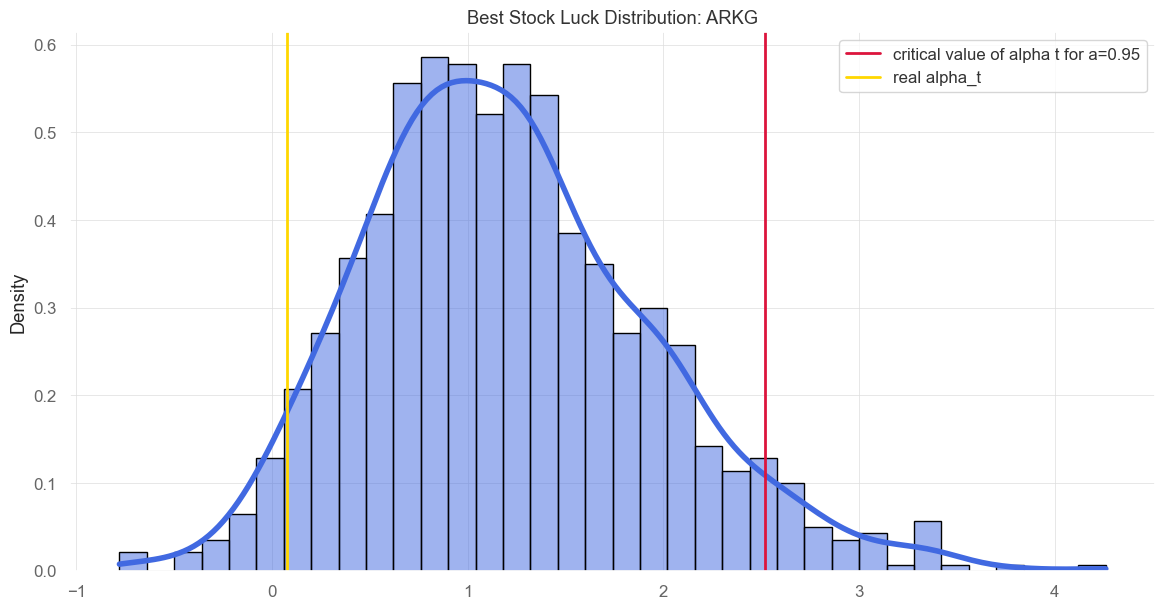

In [48]:
# Grafico luck distribution — titolo migliore (rank più alto)
luck_a = -1   # -1 = ultima colonna = rango più alto

plt.figure(figsize=(14, 7))
sns.histplot(sorted(luck_d.iloc[:, luck_a]),
             bins=int(180/5),
             color='royalblue',
             kde=True,
             stat='density',
             edgecolor='black',
             line_kws={'linewidth': 4})

plt.axvline(np.percentile(luck_d.iloc[:, luck_a], 95),
            label='critical value of alpha t for a=0.95',
            color='crimson', linewidth=2)
plt.axvline(sorted_original.iloc[luck_a, 0],
            label='real alpha_t',
            color='gold', linewidth=2)

plt.title(f"Best Stock Luck Distribution: {sorted_original.index[luck_a]}")
plt.legend()
plt.show()

La procedura di bootstrap cross-sezionale (Cuthbertson et al., 2008) permette di 
costruire la **luck distribution** — la distribuzione dei t-alpha che un fondo 
potrebbe ottenere per pura fortuna sotto l'ipotesi nulla di alpha = 0.

Il grafico mostra la luck distribution per il **miglior ETF simulato** (rango più 
alto tra le 1000 simulazioni). La linea rossa indica il valore critico al 95° 
percentile (~2.4): un fondo è classificato come skilled solo se il suo t-alpha 
reale supera questa soglia. La linea gialla indica il t-alpha osservato di ARKG 
(~0.08), il migliore tra i cinque ETF ARK.

Il risultato è netto: **nessun ETF ARK supera la soglia della luck distribution**.
Il t-alpha reale cade nel pieno centro della distribuzione simulata — 
indistinguibile dalla fortuna.

| ETF | Classificazione |
|-----|----------------|
| ARKK | Luck |
| ARKW | Luck |
| ARKG | Luck |
| ARKF | Luck |
| ARKQ | Luck |

Questo risultato è coerente con le conclusioni di Cuthbertson et al. (2008) sui 
fondi UK: la maggior parte dei fondi attivi non genera alpha persistente al netto 
del rischio sistematico. ARK non fa eccezione — la performance straordinaria del 
2020 era prevalentemente il prodotto di esposizioni fattoriali favorevoli in un 
regime di mercato eccezionale, non di genuina capacità di stock-picking.

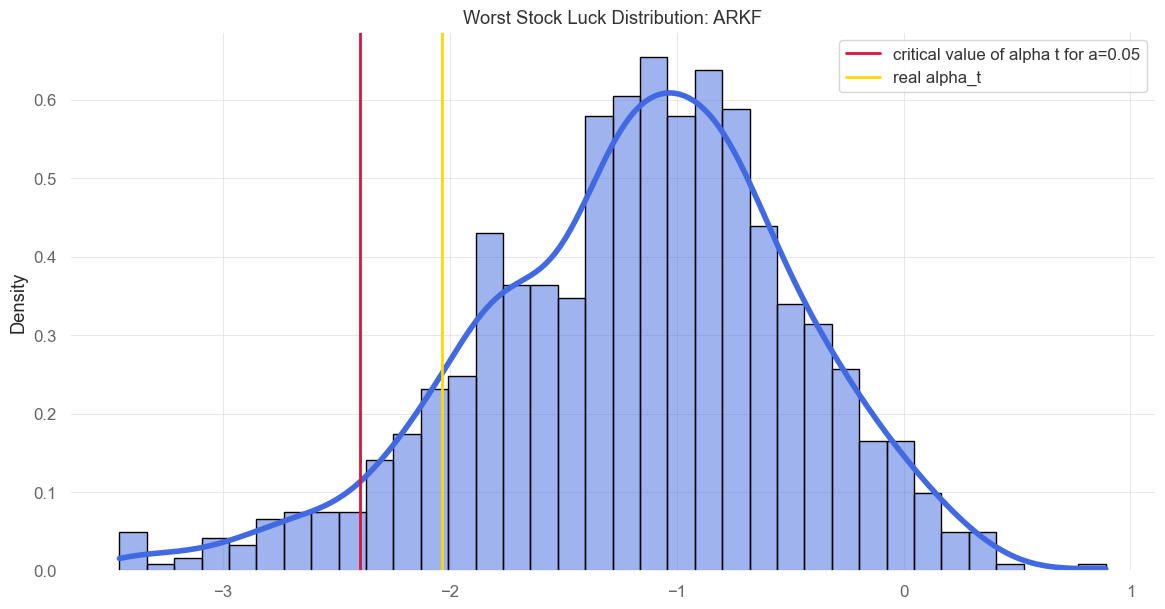

In [49]:
# Grafico luck distribution — titolo peggiore (rank più basso)
unluck_a = 0   # 0 = prima colonna = rango più basso

plt.figure(figsize=(14, 7))
sns.histplot(sorted(luck_d.iloc[:, unluck_a]),
             bins=int(180/5),
             color='royalblue',
             kde=True,
             stat='density',
             edgecolor='black',
             line_kws={'linewidth': 4})

plt.axvline(np.percentile(luck_d.iloc[:, unluck_a], 5),
            label='critical value of alpha t for a=0.05',
            color='crimson', linewidth=2)
plt.axvline(sorted_original.iloc[unluck_a, 0],
            label='real alpha_t',
            color='gold', linewidth=2)

plt.title(f"Worst Stock Luck Distribution: {sorted_original.index[unluck_a]}")
plt.legend()
plt.show()

Il grafico mostra la luck distribution per il **peggior ETF simulato** (rango più 
basso). In questo caso la soglia rilevante è il **5° percentile** della distribuzione 
(linea rossa, ~-2.6): un fondo è classificato come **bad skill** solo se il suo 
t-alpha reale scende al di sotto di questa soglia.

La linea gialla indica il t-alpha reale di ARKF (~-2.0), il peggiore tra i cinque 
ETF ARK. Nonostante ARKF avesse mostrato un alpha OLS significativamente negativo 
(-1.49**, ~-18% annuo) nella regressione statica, il bootstrap non lo classifica 
come bad skill, il suo t-alpha reale cade **a destra** del valore critico, ancora 
all'interno della luck distribution.

Questo illustra la differenza fondamentale tra i due approcci:

- **OLS classico** — valuta ogni fondo in isolamento, ignorando il problema dei 
test multipli. Con 5 fondi testati simultaneamente, la probabilità di trovare 
almeno un alpha significativo per puro caso aumenta.
- **Bootstrap cross-sezionale**, costruisce la distribuzione del caso peggiore 
simulato e confronta il t-alpha reale con essa. È un test più severo e più corretto 
quando si valutano più fondi contemporaneamente.

Il verdetto finale è quindi univoco: **nessun ETF ARK mostra evidenza di skill 
genuino o bad skill sistematico**, la performance, positiva o negativa, è 
statisticamente indistinguibile dalla fortuna una volta corretti per le esposizioni 
fattoriali.

## Out Of Sample Performance

In [50]:
# Dati in-sample e out-of-sample
y_is  = capm4_is[etf_tickers]
y_oos = capm4_oos[etf_tickers]
x_oos = capm4_oos[['Mkt-RF', 'SMB', 'HML', 'Mom']]

spy_oos = capm4_oos['SPY']

In [51]:
# Medie e covarianza in-sample
ER_means  = y_is.mean()
covmatrix = y_is.cov()

# Tangency Portfolio (Max Sharpe, no short-selling)
ef     = EfficientFrontier(ER_means, covmatrix, weight_bounds=(0, 1), solver='CLARABEL')
ef_opt = ef.deepcopy(); ef_opt.max_sharpe(risk_free_rate=0)
perf_opt = ef_opt.portfolio_performance(risk_free_rate=0)
w_opt    = ef_opt.clean_weights()

print("Pesi Tangency Portfolio (in-sample):")
print(pd.Series(w_opt).round(4))

Pesi Tangency Portfolio (in-sample):
ARKF    0.0
ARKG    0.0
ARKK    0.0
ARKQ    1.0
ARKW    0.0
dtype: float64


In [52]:
# Pesi come array allineati alle colonne di y_oos
pesi_opt = pd.Series(w_opt).reindex(etf_tickers).values
pesi_ew  = np.ones(len(etf_tickers)) / len(etf_tickers)

# Serie rendimenti OOS
ptf_opt = y_oos.dot(pesi_opt)
ptf_ew  = y_oos.dot(pesi_ew)
ptf_spy = spy_oos

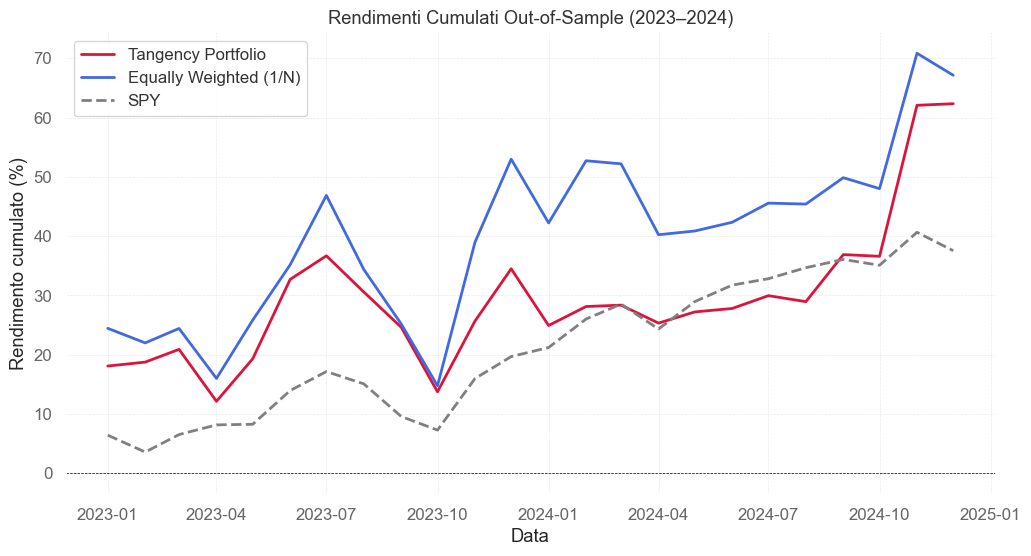

In [53]:
plt.figure(figsize=(12, 6))

plt.plot(ptf_opt.cumsum(), color='crimson',   linewidth=2, label='Tangency Portfolio')
plt.plot(ptf_ew.cumsum(),  color='royalblue', linewidth=2, label='Equally Weighted (1/N)')
plt.plot(ptf_spy.cumsum(), color='gray',      linewidth=2, linestyle='--', label='SPY')

plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.title('Rendimenti Cumulati Out-of-Sample (2023–2024)')
plt.xlabel('Data')
plt.ylabel('Rendimento cumulato (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [54]:
# Metriche di performance OOS con quantstats
metriche_oos = {}

for nome, serie in [('Tangency', ptf_opt), ('Equal Weight', ptf_ew), ('SPY', ptf_spy)]:
    r = serie / 100
    metriche_oos[nome] = {
        'CAGR (%)':        round(qs.stats.cagr(r, periods=12) * 100, 2),
        'Sharpe (ann.)':   round(qs.stats.sharpe(r, periods=12), 3),
        'Sortino (ann.)':  round(qs.stats.sortino(r, periods=12), 3),
        'Max Drawdown (%)':round(qs.stats.max_drawdown(r) * 100, 2),
    }

pd.DataFrame(metriche_oos).T

,CAGR (%),Sharpe (ann.),Sortino (ann.),Max Drawdown (%)
Tangency,30.70,1.035,2.293,-21.31
Equal Weight,30.26,0.865,1.791,-28.82
SPY,19.60,1.499,3.039,-9.59


In [55]:
# Alpha OOS — regressione Carhart sul periodo 2023–2024
x_oos_const = sm.add_constant(x_oos)

reg_oos_opt = sm.OLS(ptf_opt, x_oos_const).fit()
reg_oos_ew  = sm.OLS(ptf_ew,  x_oos_const).fit()
reg_oos_spy = sm.OLS(ptf_spy, x_oos_const).fit()

summary_col([reg_oos_opt, reg_oos_ew, reg_oos_spy],
            model_names=['Tangency', 'Equal Weight', 'SPY'],
            stars=True)

,Tangency,Equal Weight,SPY
const,0.9445,-0.0890,-0.0330
,(1.0692),(1.0796),(0.0931)
Mkt-RF,1.0717***,1.8796***,0.9780***
,(0.2847),(0.2875),(0.0248)
SMB,1.4343***,1.3743***,-0.1090***
,(0.4184),(0.4225),(0.0364)
HML,-0.6709**,-0.5468*,0.0024
,(0.3085),(0.3115),(0.0269)
Mom,-0.0669,-0.1441,-0.0161
,(0.2788),(0.2815),(0.0243)


In [56]:
# Calcolo punti sulla frontiera efficiente
target_returns = np.linspace(ER_means.min(), ER_means.max(), 100)
vols_ef    = []
returns_ef = []

for tr in target_returns:
    try:
        ef_tmp = EfficientFrontier(ER_means, covmatrix, weight_bounds=(0, 1), solver='CLARABEL')
        ef_tmp.efficient_return(tr)
        p = ef_tmp.portfolio_performance(risk_free_rate=0)
        returns_ef.append(p[0])
        vols_ef.append(p[1])
    except:
        pass

vols_ef    = np.array(vols_ef)
returns_ef = np.array(returns_ef)

In [57]:
# Min Variance Portfolio
ef_min   = EfficientFrontier(ER_means, covmatrix, weight_bounds=(0, 1), solver='CLARABEL')
ef_min.min_volatility()
perf_min = ef_min.portfolio_performance(risk_free_rate=0)

In [58]:
# Simulazione Montecarlo
n_sim    = 10000
n_assets = len(ER_means)

mc_returns = []
mc_vols    = []
mc_sharpes = []

rng = np.random.default_rng(42)
for i in range(n_sim):
    w   = rng.dirichlet(np.ones(n_assets))
    ret = np.dot(w, ER_means)
    vol = np.sqrt(np.dot(w, np.dot(covmatrix, w)))
    mc_returns.append(ret)
    mc_vols.append(vol)
    mc_sharpes.append(ret / vol)

mc_returns = np.array(mc_returns)
mc_vols    = np.array(mc_vols)
mc_sharpes = np.array(mc_sharpes)
best       = np.argmax(mc_sharpes)

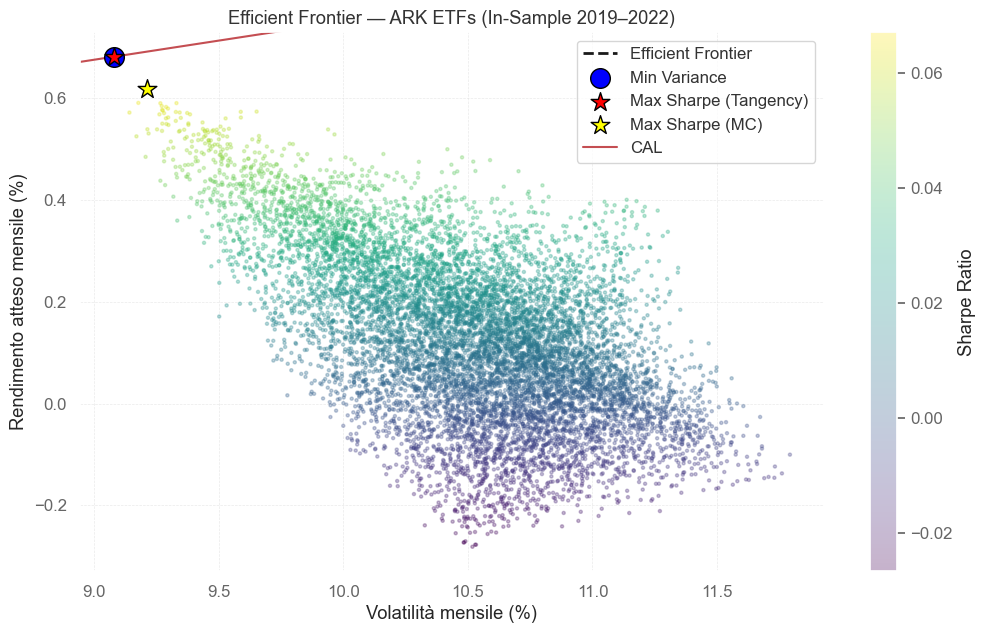

In [59]:
plt.figure(figsize=(12, 7))

# Cloud Montecarlo
sc = plt.scatter(mc_vols, mc_returns, s=5, alpha=0.3, c=mc_sharpes, cmap='viridis')
plt.colorbar(sc, label='Sharpe Ratio')

# Frontiera efficiente
plt.plot(vols_ef, returns_ef, 'k--', linewidth=2, label='Efficient Frontier')

# Min Variance
plt.scatter(perf_min[1], perf_min[0], c='blue', s=200, marker='o',
            edgecolors='black', label='Min Variance', zorder=10)

# Tangency Portfolio
plt.scatter(perf_opt[1], perf_opt[0], c='red', s=200, marker='*',
            edgecolors='black', label='Max Sharpe (Tangency)', zorder=10)

# Max Sharpe Montecarlo
plt.scatter(mc_vols[best], mc_returns[best], c='yellow', s=200, marker='*',
            edgecolors='black', label='Max Sharpe (MC)', zorder=10)

# CAL
xl = plt.xlim(); yl = plt.ylim()
cal_x = np.linspace(0, xl[1], 100)
cal_y = perf_opt[2] * cal_x
plt.plot(cal_x, cal_y, 'r-', linewidth=1.5, label='CAL')
plt.xlim(xl); plt.ylim(yl)

plt.title('Efficient Frontier — ARK ETFs (In-Sample 2019–2022)')
plt.xlabel('Volatilità mensile (%)')
plt.ylabel('Rendimento atteso mensile (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()